# Multivariate ARIMA/VAR Forecasting of Food Inflation Using ONI

### Objective

This notebook develops a multivariate time-series forecasting model to predict
India's Consumer Food Price Inflation (CFPI) using its own historical values
and the Oceanic Niño Index (ONI).

The multivariate autoregressive formulation is implemented using a Vector
Autoregression (VAR) model, where food inflation and ONI are treated as
endogenous time-series variables.

### Target Variable
- Food Inflation

### Predictor / Endogenous Variable
- Oceanic Niño Index (ONI)

### Forecasting Period
The model is trained chronologically and evaluated on a held-out future
test period to avoid temporal data leakage.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# load dataset
df = pd.read_csv("../data/processed/cpi_oni.csv")

In [3]:
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

In [4]:
display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate dates:")
print(df["date"].duplicated().sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Dataset shape: (168, 4)

Columns:
['date', 'food_inflation', 'oni', 'month']

Missing values:
date              0
food_inflation    0
oni               0
month             0
dtype: int64

Duplicate dates:
0

Date range:
2012-01-01 00:00:00 to 2025-12-01 00:00:00


In [6]:
var_df = df[
    ["date", "food_inflation", "oni"]
].copy()

var_df = var_df.set_index("date")

# Explicitly assign monthly frequency
var_df = var_df.asfreq("MS")

display(var_df.head())
display(var_df.tail())

,food_inflation,oni
date,,
2012-01-01,-0.21,-0.72
2012-02-01,4.45,-0.57
2012-03-01,7.09,-0.46
2012-04-01,9.32,-0.36
2012-05-01,9.70,-0.17


,food_inflation,oni
date,,
2025-08-01,-0.64,-0.28
2025-09-01,-2.33,-0.40
2025-10-01,-5.02,-0.51
2025-11-01,-3.91,-0.55
2025-12-01,-2.71,-0.54


In [7]:
TEST_SIZE = 24

train = var_df.iloc[:-TEST_SIZE].copy()
test = var_df.iloc[-TEST_SIZE:].copy()

print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

Training period:
2012-01-01 00:00:00 to 2023-12-01 00:00:00

Testing period:
2024-01-01 00:00:00 to 2025-12-01 00:00:00

Train shape: (144, 2)
Test shape: (24, 2)


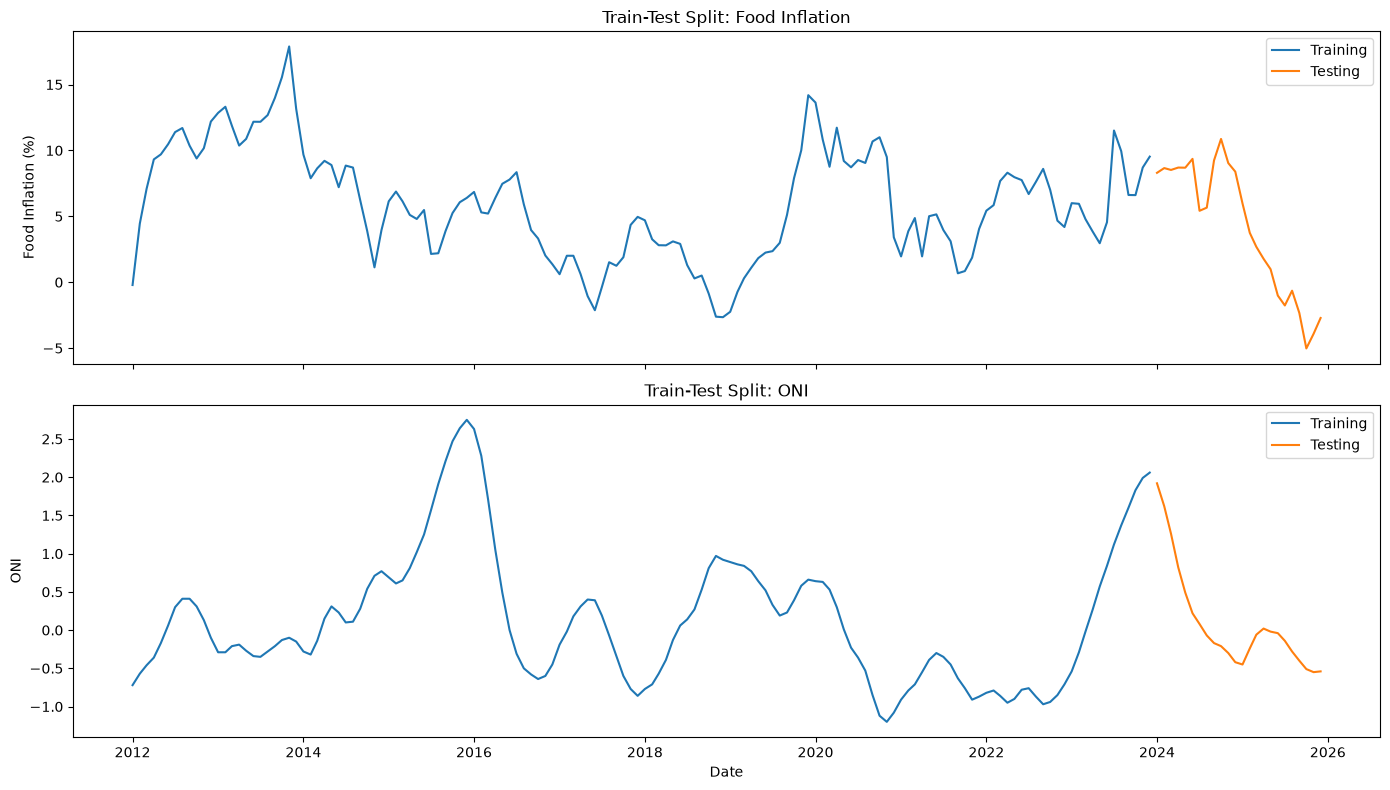

In [8]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)

axes[0].plot(
    train.index,
    train["food_inflation"],
    label="Training"
)

axes[0].plot(
    test.index,
    test["food_inflation"],
    label="Testing"
)

axes[0].set_ylabel("Food Inflation (%)")
axes[0].set_title("Train-Test Split: Food Inflation")
axes[0].legend()

axes[1].plot(
    train.index,
    train["oni"],
    label="Training"
)

axes[1].plot(
    test.index,
    test["oni"],
    label="Testing"
)

axes[1].set_ylabel("ONI")
axes[1].set_xlabel("Date")
axes[1].set_title("Train-Test Split: ONI")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")

    print(f"\n{name}")
    print("-" * 50)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")

    if result[1] < 0.05:
        print("Result        : Stationary")
    else:
        print("Result        : Non-stationary")


adf_test(train["food_inflation"], "Food Inflation")
adf_test(train["oni"], "ONI")


Food Inflation
--------------------------------------------------
ADF Statistic : -1.6377
p-value       : 0.4634
Lags Used     : 14
Observations  : 129
Result        : Non-stationary

ONI
--------------------------------------------------
ADF Statistic : -2.7091
p-value       : 0.0725
Lags Used     : 10
Observations  : 133
Result        : Non-stationary


In [10]:
train_model = train.copy()
test_model = test.copy()

food_stationary = adfuller(
    train["food_inflation"].dropna(),
    autolag="AIC"
)[1] < 0.05

oni_stationary = adfuller(
    train["oni"].dropna(),
    autolag="AIC"
)[1] < 0.05

print("Food inflation stationary:", food_stationary)
print("ONI stationary:", oni_stationary)

if not food_stationary:
    train_model["food_inflation"] = (
        train_model["food_inflation"].diff()
    )

if not oni_stationary:
    train_model["oni"] = (
        train_model["oni"].diff()
    )

train_model = train_model.dropna()

display(train_model.head())

Food inflation stationary: False
ONI stationary: False


,food_inflation,oni
date,,
2012-02-01,4.66,0.15
2012-03-01,2.64,0.11
2012-04-01,2.23,0.10
2012-05-01,0.38,0.19
2012-06-01,0.77,0.23


In [11]:
model = VAR(train_model)

lag_selection = model.select_order(
    maxlags=12,
    trend="c"
)

print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -2.141      -2.097      0.1176      -2.123
1       -3.544      -3.412     0.02890      -3.490
2       -4.005     -3.785*     0.01823      -3.916
3       -4.000      -3.693     0.01832      -3.875
4       -3.949      -3.554     0.01928      -3.788
5       -4.073      -3.590     0.01704      -3.877
6       -4.026      -3.455     0.01787      -3.794
7       -3.991      -3.333     0.01852      -3.723
8       -4.000      -3.253     0.01837      -3.696
9       -4.005      -3.171     0.01831      -3.666
10      -4.177      -3.255     0.01543      -3.803
11      -4.162      -3.153     0.01569      -3.752
12     -4.378*      -3.280    0.01267*     -3.932*
--------------------------------------------------


In [12]:
print("AIC :", lag_selection.aic)
print("BIC :", lag_selection.bic)
print("HQIC:", lag_selection.hqic)
print("FPE :", lag_selection.fpe)

AIC : 12
BIC : 2
HQIC: 12
FPE : 12


In [13]:
selected_lag = lag_selection.bic

print("Selected lag:", selected_lag)

Selected lag: 2


In [14]:
var_model = VAR(train_model)

var_results = var_model.fit(
    maxlags=selected_lag,
    trend="c"
)

print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 29, Aug, 2026
Time:                     20:07:01
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -3.87671
Nobs:                     141.000    HQIC:                  -4.00086
Log likelihood:          -102.089    FPE:                  0.0168099
AIC:                     -4.08584    Det(Omega_mle):       0.0156783
--------------------------------------------------------------------
Results for equation food_inflation
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.017526         0.137444            0.128           0.899
L1.food_inflation         0.310182         0.082285            3.770           0.000
L1.oni                   -1.646526 

In [15]:
print("Stable VAR:", var_results.is_stable(verbose=True))

Eigenvalues of VAR(1) rep
0.5158873789622201
0.5158873789622201
0.7689576717027613
0.7689576717027613
Stable VAR: True


In [16]:
whiteness_test = var_results.test_whiteness(
    nlags=12
)

print(whiteness_test)

<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 91.597, critical value: 55.758>, p-value: 0.000>


In [17]:
lag_order = var_results.k_ar

forecast_input = train_model.values[-lag_order:]

forecast = var_results.forecast(
    y=forecast_input,
    steps=len(test_model)
)

forecast_df = pd.DataFrame(
    forecast,
    index=test_model.index,
    columns=test_model.columns
)

display(forecast_df.head())

,food_inflation,oni
date,,
2024-01-01,-0.099056,0.008345
2024-02-01,-0.117890,-0.026808
2024-03-01,0.066505,-0.039417
2024-04-01,0.085119,-0.035372
2024-05-01,0.012506,-0.021976


In [18]:
food_differenced = not food_stationary
oni_differenced = not oni_stationary

print("Food differenced:", food_differenced)
print("ONI differenced:", oni_differenced)

Food differenced: True
ONI differenced: True


In [19]:
if food_differenced:
    food_forecast = (
        train["food_inflation"].iloc[-1]
        + forecast_df["food_inflation"].cumsum()
    )
else:
    food_forecast = forecast_df["food_inflation"]


if oni_differenced:
    oni_forecast = (
        train["oni"].iloc[-1]
        + forecast_df["oni"].cumsum()
    )
else:
    oni_forecast = forecast_df["oni"]

In [20]:
predictions = pd.DataFrame({
    "actual_food_inflation": test["food_inflation"],
    "predicted_food_inflation": food_forecast,
    "actual_oni": test["oni"],
    "predicted_oni": oni_forecast
})

display(predictions.head())

,actual_food_inflation,predicted_food_inflation,actual_oni,predicted_oni
date,,,,
2024-01-01,8.30,9.430944,1.92,2.068345
2024-02-01,8.66,9.313054,1.62,2.041538
2024-03-01,8.52,9.379559,1.26,2.002121
2024-04-01,8.70,9.464678,0.82,1.966749
2024-05-01,8.69,9.477185,0.49,1.944773


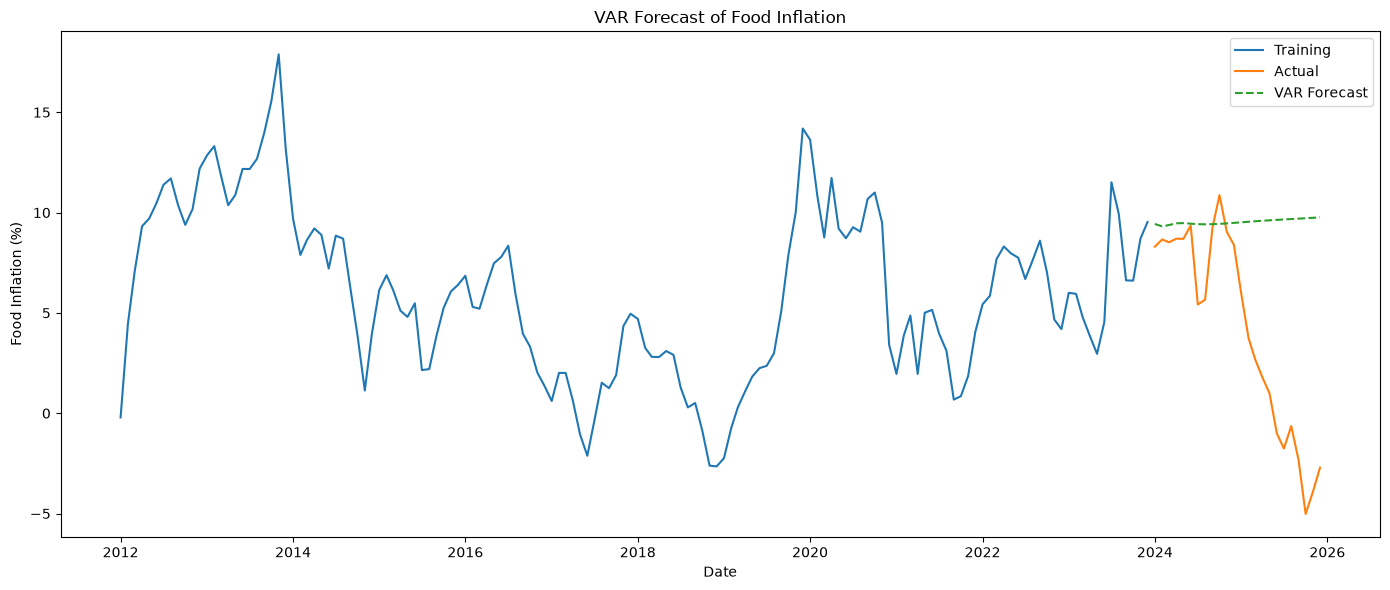

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train["food_inflation"],
    label="Training"
)

plt.plot(
    test.index,
    test["food_inflation"],
    label="Actual"
)

plt.plot(
    predictions.index,
    predictions["predicted_food_inflation"],
    label="VAR Forecast",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("VAR Forecast of Food Inflation")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
actual = predictions["actual_food_inflation"]
predicted = predictions["predicted_food_inflation"]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

smape = (
    100
    * np.mean(
        2 * np.abs(actual - predicted)
        / (
            np.abs(actual)
            + np.abs(predicted)
            + 1e-8
        )
    )
)

print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"sMAPE : {smape:.2f}%")

MAE   : 5.5455
RMSE  : 7.4160
sMAPE : 88.73%


In [23]:
forecast_results = predictions.copy()

forecast_results["error"] = (
    forecast_results["actual_food_inflation"]
    - forecast_results["predicted_food_inflation"]
)

forecast_results["absolute_error"] = (
    forecast_results["error"].abs()
)

display(forecast_results)

,actual_food_inflation,predicted_food_inflation,actual_oni,predicted_oni,error,absolute_error
date,,,,,,
2024-01-01,8.30,9.430944,1.92,2.068345,-1.130944,1.130944
2024-02-01,8.66,9.313054,1.62,2.041538,-0.653054,0.653054
2024-03-01,8.52,9.379559,1.26,2.002121,-0.859559,0.859559
2024-04-01,8.70,9.464678,0.82,1.966749,-0.764678,0.764678
2024-05-01,8.69,9.477185,0.49,1.944773,-0.787185,0.787185
2024-06-01,9.36,9.447601,0.22,1.938847,-0.087601,0.087601
2024-07-01,5.42,9.422201,0.08,1.947068,-4.002201,4.002201
2024-08-01,5.66,9.415278,-0.07,1.965331,-3.755278,3.755278
2024-09-01,9.24,9.422330,-0.17,1.989132,-0.182330,0.182330
